# Amazon Best Seller Prediction and Recommendation System

In [1]:
import pandas as pd 
df = pd.read_csv("amazon.csv")
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [2]:
df.tail()

,Name,Author,User Rating,Reviews,Price,Year,Genre
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction
549,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2019,Non Fiction


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB


In [4]:
df.describe()

,User Rating,Reviews,Price,Year
count,550.000000,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,13.100000,2014.000000
std,0.226980,11731.132017,10.842262,3.165156
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


In [5]:
df.shape

(550, 7)

In [6]:
df.columns

Index(['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre'], dtype='object')

In [7]:
df.isnull().sum()

Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64

In [8]:
df["Genre"] = df["Genre"].map({"Fiction" : 0, "Non Fiction" : 1})
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,1
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,0
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,1
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,0
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,1


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

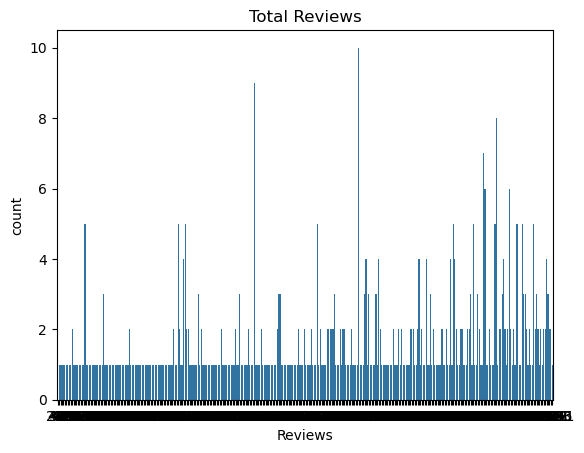

In [10]:
sns.countplot(x = "Reviews", data = df)
plt.title("Total Reviews")
plt.show()

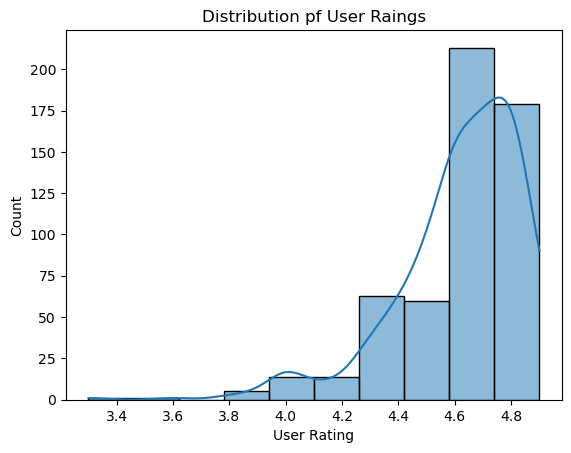

In [11]:
sns.histplot(df["User Rating"], bins = 10, kde = True)
plt.title("Distribution pf User Raings")
plt.show()

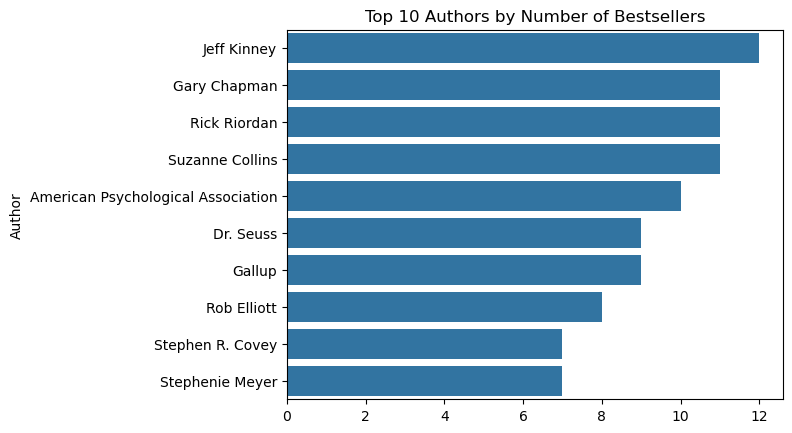

In [12]:
top_authors = df["Author"].value_counts().head(10)
sns.barplot(x = top_authors.values, y = top_authors.index)
plt.title("Top 10 Authors by Number of Bestsellers")
plt.show()

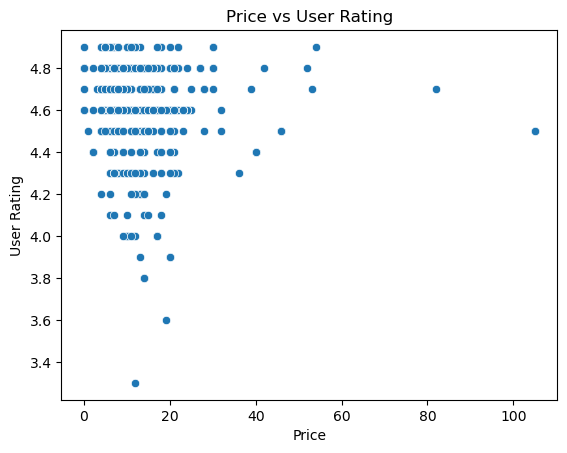

In [13]:
sns.scatterplot(x = "Price", y = "User Rating", data = df)
plt.title("Price vs User Rating")
plt.show()

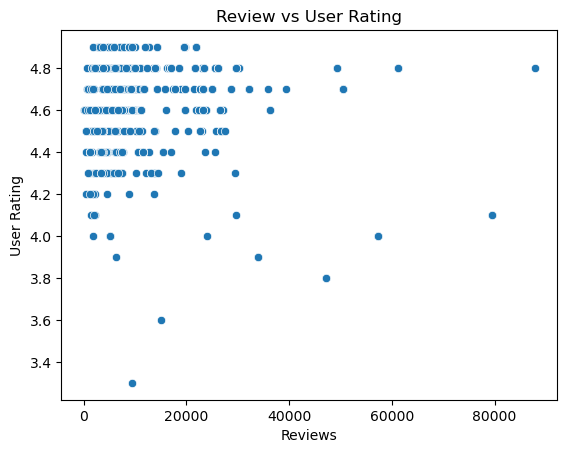

In [15]:
sns.scatterplot(x = "Reviews", y = "User Rating", data = df)
plt.title("Review vs User Rating")
plt.show()

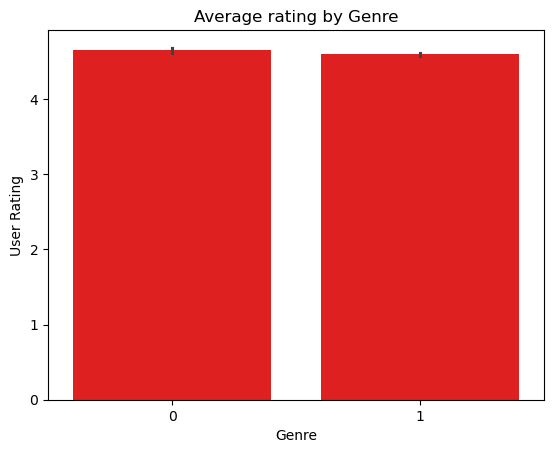

In [22]:
sns.barplot(x = "Genre", y = "User Rating", data = df, color = "red")
plt.title("Average rating by Genre")
plt.show()

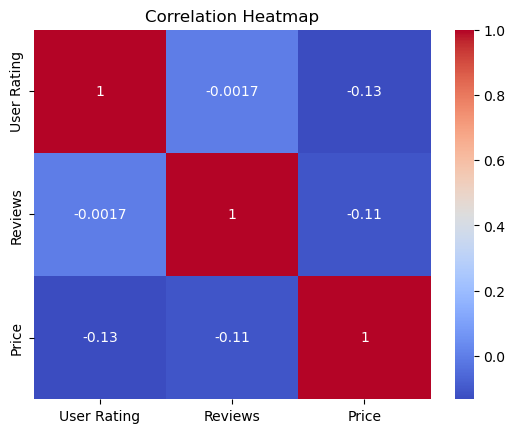

In [18]:
corr = df[["User Rating", "Reviews", "Price"]].corr()
sns.heatmap(corr, annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [24]:
df["Bestseller"] = (df['User Rating'] > 4.5).astype(int)

X = df[["Reviews", "Price", "Genre"]]
y = df["Bestseller"]

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)



RandomForestClassifier()

In [30]:
print("Accuracy :", model.score(X_test, y_test))

Accuracy : 0.8181818181818182


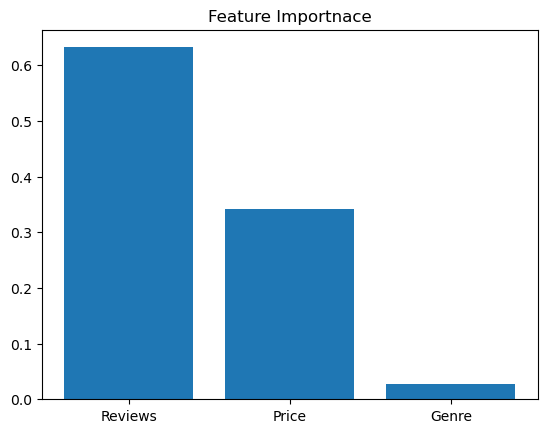

In [31]:
importance = model.feature_importances_

plt.bar(['Reviews', 'Price', 'Genre'], importance)
plt.title("Feature Importnace")
plt.show()

In [33]:
from sklearn.metrics.pairwise import cosine_similarity

features = df[['User Rating', 'Reviews', 'Price']]

similarity = cosine_similarity(features)

def recommend(index):
    scores = list(enumerate(similarity[index]))
    scores = sorted(scores, key = lambda x : x[1], reverse = True)

    for i in scores[1:6]:
        print(df.iloc[i[0]]['Name'])

recommend(1)

Super Freakonomics: Global Cooling, Patriotic Prostitutes, and Why Suicide Bombers Should Buy Life Insurance
Watchmen
Capital in the Twenty First Century
The 17 Day Diet: A Doctor's Plan Designed for Rapid Results
Thomas Jefferson: The Art of Power


In [34]:
features = df[['User Rating', 'Reviews', 'Price']]

similarity = cosine_similarity(features)

def recommend(index):
    scores = list(enumerate(similarity[index]))
    scores = sorted(scores, key = lambda x : x[1], reverse = True)

    for i in scores[1:6]:
        print(df.iloc[i[0]]['Name'])

recommend(0)

Milk and Honey
Milk and Honey
Milk and Honey
Fire and Fury: Inside the Trump White House
Jesus Calling: Enjoying Peace in His Presence (with Scripture References)


In [35]:
import pickle
with open('bestseller_model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [36]:
# Load the model
with open('bestseller_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Test prediction
loaded_model.predict(X_test)

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0])